#Hospital Length of Stay Prediction Using Machine Learning
This project develops ML models to predict a patient's hospital length of stay based on demographic and clinical information.

##Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#About Dataset
The dataset has been taken from the following website which contains the full data description: https://microsoft.github.io/r-server-hospital-length-of-stay/input_data.html

In [6]:
df = pd.read_csv('LengthOfStay.csv')


#Exploratory Data Analysis

In [7]:
df.head()

,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,...,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,...,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,...,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,...,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,...,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   eid                         100000 non-null  int64  
 1   vdate                       100000 non-null  object 
 2   rcount                      100000 non-null  object 
 3   gender                      100000 non-null  object 
 4   dialysisrenalendstage       100000 non-null  int64  
 5   asthma                      100000 non-null  int64  
 6   irondef                     100000 non-null  int64  
 7   pneum                       100000 non-null  int64  
 8   substancedependence         100000 non-null  int64  
 9   psychologicaldisordermajor  100000 non-null  int64  
 10  depress                     100000 non-null  int64  
 11  psychother                  100000 non-null  int64  
 12  fibrosisandother            100000 non-null  int64  
 13  malnutrition   

No missing values

In [9]:
df.describe()

,eid,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,...,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,lengthofstay
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000
mean,50000.500000,0.036420,0.035270,0.094940,0.039450,0.063060,0.239040,0.051660,0.049390,0.004790,...,10.177455,137.891397,141.963384,14.097185,1.099350,29.805759,73.444720,6.493768,2.123310,4.00103
std,28867.657797,0.187334,0.184462,0.293134,0.194664,0.243072,0.426499,0.221341,0.216682,0.069044,...,5.353131,2.999669,29.992996,12.952454,0.200262,2.003769,11.644555,0.568473,2.050641,2.36031
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.100000,124.912632,-1.005927,1.000000,0.219770,21.992683,21.000000,0.200000,0.000000,1.00000
25%,25000.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.700000,135.871062,121.682383,11.000000,0.964720,28.454235,66.000000,6.500000,1.000000,2.00000
50%,50000.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,9.400000,137.887151,142.088545,12.000000,1.098764,29.807516,73.000000,6.500000,1.000000,4.00000
75%,75000.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,11.500000,139.912885,162.180996,14.000000,1.234867,31.156885,81.000000,6.500000,3.000000,6.00000
max,100000.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,245.900000,151.387283,271.444277,682.500000,2.035202,38.935293,130.000000,10.000000,10.000000,17.00000


Negative minimum glucose value. Physiologically impossible and should be corrected before training

In [10]:
df.duplicated().sum()

np.int64(0)

No duplicate patient records

In [11]:
print(df["gender"].unique())
print(df["rcount"].unique())

['F' 'M']
['0' '5+' '1' '3' '4' '2']


In [12]:
df[df["glucose"] < 0]

,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
59774,59775,11/27/2012,4,M,0,0,0,0,0,0,...,-1.005927,12.0,0.703748,28.503134,82,6.5,1,12/4/2012,A,7


#Data Cleaning

In [13]:
df.loc[df["glucose"] < 0, "glucose"] = np.nan
df["glucose"] = df["glucose"].fillna(df["glucose"].median())


Negative glucose value replaced with median glucose level

In [14]:
df = df.drop(columns=["eid", "vdate", "discharged", "facid"])


Removed identifier and administrative columns

In [15]:
df["rcount"] = (df["rcount"].replace("5+", "5").astype(int))


Converted readmission count

In [16]:
df["gender"] = df["gender"].map({"F": 0, "M": 1})


Encode gender

#Feature Engineering

In [17]:
issue_columns = [
    "dialysisrenalendstage",
    "asthma",
    "irondef",
    "pneum",
    "substancedependence",
    "psychologicaldisordermajor",
    "depress",
    "psychother",
    "fibrosisandother",
    "malnutrition",
    "hemo"
]

df["total_issues"] = df[issue_columns].sum(axis=1)

The 'total_issues' feature counts the number of chronic conditions recorded for each patient

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   rcount                      100000 non-null  int64  
 1   gender                      100000 non-null  int64  
 2   dialysisrenalendstage       100000 non-null  int64  
 3   asthma                      100000 non-null  int64  
 4   irondef                     100000 non-null  int64  
 5   pneum                       100000 non-null  int64  
 6   substancedependence         100000 non-null  int64  
 7   psychologicaldisordermajor  100000 non-null  int64  
 8   depress                     100000 non-null  int64  
 9   psychother                  100000 non-null  int64  
 10  fibrosisandother            100000 non-null  int64  
 11  malnutrition                100000 non-null  int64  
 12  hemo                        100000 non-null  int64  
 13  hematocrit     

#Preparing the Data

In [19]:
X = df.drop("lengthofstay", axis=1)

y = df["lengthofstay"]

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Eighty percent for training, twenty percent for testing

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Standardize features for linear and ridge regression

#Linear Regression
Baseline linear model

In [22]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

LinearRegression()

In [23]:
y_pred_lr = model_lr.predict(X_test_scaled)

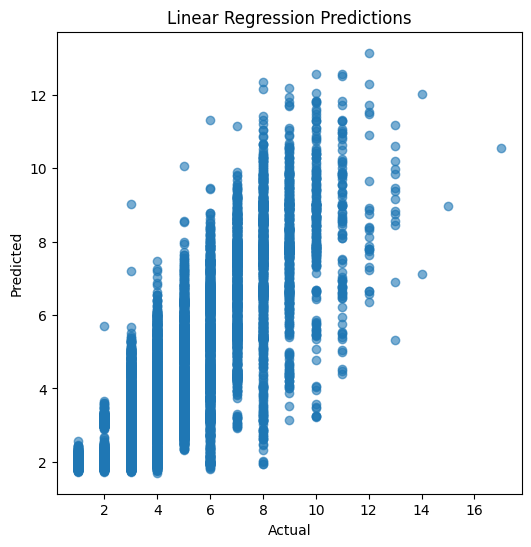

In [24]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression Predictions")
plt.show()

In [25]:
from sklearn.metrics import r2_score, root_mean_squared_error

score_lr = r2_score(y_test, y_pred_lr)
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)

print(f"R²: {score_lr}")
print(f"RMSE: {rmse_lr}")

R²: 0.7522035308937851
RMSE: 1.1660651314289303


#Ridge Regression
Regularized linear model

In [26]:
from sklearn.linear_model import Ridge

model_rg = Ridge(alpha=1.0)
model_rg.fit(X_train_scaled, y_train)

Ridge()

In [27]:
y_pred_rg = model_rg.predict(X_test_scaled)

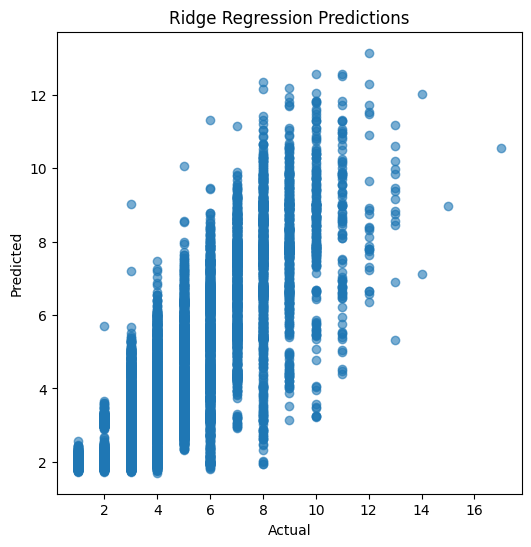

In [28]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rg, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Ridge Regression Predictions")
plt.show()

In [29]:
score_rg = r2_score(y_test, y_pred_rg)
rmse_rg = root_mean_squared_error(y_test, y_pred_rg)

print(f"Ridge Regression R²: {score_rg}")
print(f"Ridge Regression RMSE: {rmse_rg}")

Ridge Regression R²: 0.7522036964042061
Ridge Regression RMSE: 1.1660647420045696


#Decision Tree
Single tree model

In [30]:
from sklearn.tree import DecisionTreeRegressor

model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [31]:
y_pred_dt = model_dt.predict(X_test)

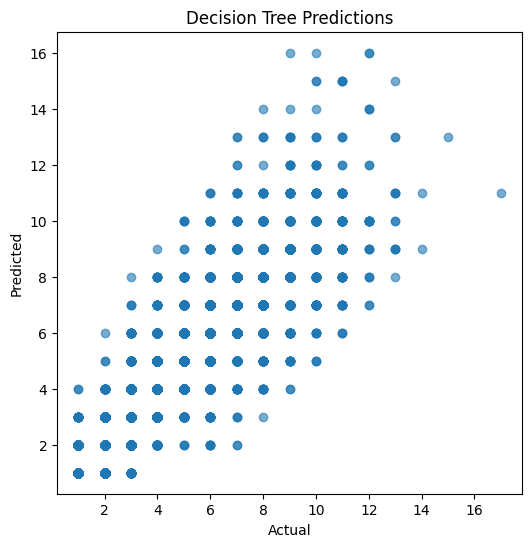

In [32]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_dt, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Decision Tree Predictions")
plt.show()

In [33]:
score_dt = r2_score(y_test, y_pred_dt)
rmse_dt = root_mean_squared_error(y_test, y_pred_dt)

print(f"Decision Tree R²: {score_dt}")
print(f"Decision Tree RMSE: {rmse_dt}")

Decision Tree R²: 0.8759020177879946
Decision Tree RMSE: 0.8251969461892112


#Random Forest
Bagging ensemble model

In [34]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [35]:
y_pred_rf = model_rf.predict(X_test)

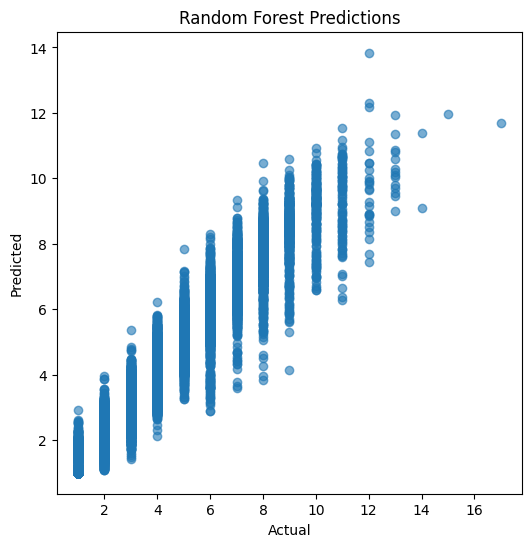

In [36]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Predictions")
plt.show()

In [37]:
score_rf = r2_score(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)

print(f"Random Forest R²: {score_rf}")
print(f"Random Forest RMSE: {rmse_rf}")

Random Forest R²: 0.9410499147452602
Random Forest RMSE: 0.5687448417348504


#XGBoost
Boosting ensemble model

In [38]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [39]:
y_pred_xgb = model_xgb.predict(X_test)

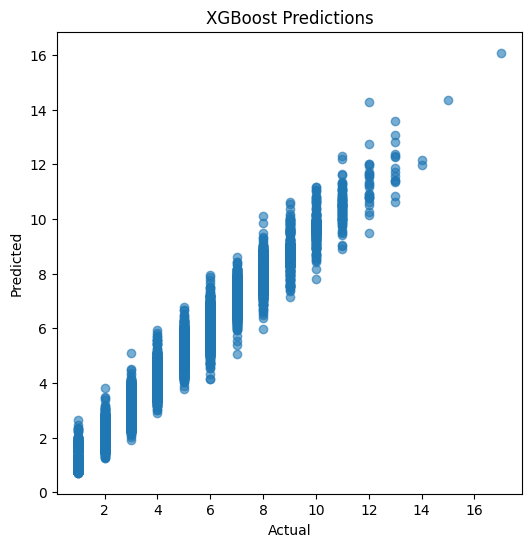

In [40]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("XGBoost Predictions")
plt.show()

In [41]:
score_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)

print(f"XGBoost R²: {score_xgb}")
print(f"XGBoost RMSE: {rmse_xgb}")

XGBoost R²: 0.9712181091308594
XGBoost RMSE: 0.3974064886569977


#Model Comparison

In [42]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "R²": [
        score_lr,
        score_rg,
        score_dt,
        score_rf,
        score_xgb
    ],
    "RMSE": [
        rmse_lr,
        rmse_rg,
        rmse_dt,
        rmse_rf,
        rmse_xgb
    ]
})

comparison

,Model,R²,RMSE
0,Linear Regression,0.752204,1.166065
1,Ridge Regression,0.752204,1.166065
2,Decision Tree,0.875902,0.825197
3,Random Forest,0.941050,0.568745
4,XGBoost,0.971218,0.397406


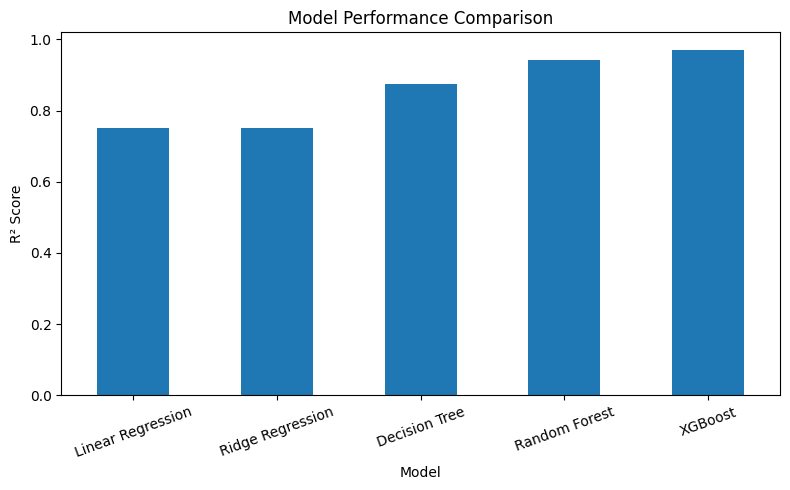

In [43]:
comparison.plot(
    x="Model",
    y="R²",
    kind="bar",
    legend=False,
    rot=20,
    figsize=(8,5)
)

plt.ylabel("R² Score")
plt.title("Model Performance Comparison")
plt.tight_layout()
plt.show()

#Conclusion
Model evaluation showed a clear improvement as more advanced algorithms were introduced. Linear Regression and Ridge Regression achieved similar performance (R² ≈ 0.75), indicating that a purely linear relationship was insufficient to explain the variation in hospital length of stay. Decision Tree Regression improved prediction accuracy by capturing nonlinear patterns, while Random Forest further reduced prediction error through ensemble learning.

Among all evaluated models, XGBoost produced the best performance, achieving an R² score of 0.971 and an RMSE of 0.397. This indicates that the model explains approximately 97% of the variation in hospital length of stay while maintaining the lowest prediction error of all models tested.

Overall, the results demonstrate that ensemble tree-based methods are well suited for this dataset, with XGBoost providing the most accurate predictions. Future work could explore hyperparameter optimization, cross-validation, and additional clinically relevant features to further validate and potentially improve model performance.